In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('diabetes1.csv')

In [3]:
df.shape

(253680, 22)

In [4]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


C:\Users\lahir\AppData\Local\Temp\ipykernel_6324\1672119213.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_binary', data=df, ax=axes[0], palette='pastel')


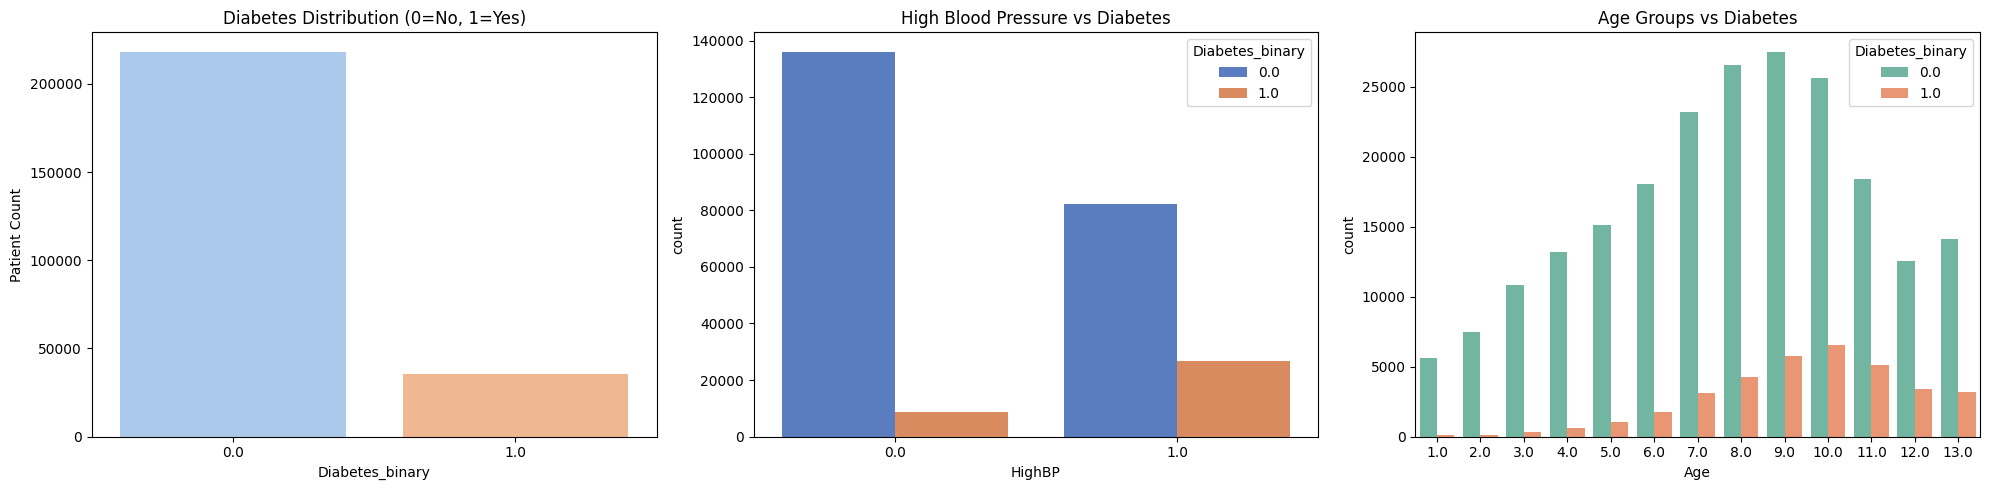

In [5]:
# ප්‍රස්ථාර 3ක් එක පෙළට ඇඳීමට තලයක් සාදා ගැනීම
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Graph 1: දියවැඩියාව තියෙන සහ නැති අයගේ ව්‍යාප්තිය (Target Variable)
sns.countplot(x='Diabetes_binary', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Diabetes Distribution (0=No, 1=Yes)')
axes[0].set_ylabel('Patient Count')

# Graph 2: අධික රුධිර පීඩනය (HighBP) සහ දියවැඩියාව අතර සම්බන්ධය
sns.countplot(x='HighBP', hue='Diabetes_binary', data=df, ax=axes[1], palette='muted')
axes[1].set_title('High Blood Pressure vs Diabetes')

# Graph 3: වයස (Age) සහ දියවැඩියාව අතර සම්බන්ධය
# (මෙහි Age යනු 1 සිට 13 දක්වා කාණ්ඩ කර ඇති වයස් කාණ්ඩ වේ)
sns.countplot(x='Age', hue='Diabetes_binary', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Age Groups vs Diabetes')

plt.tight_layout()
plt.show()

In [6]:
# 1. අනවශ්‍ය Columns ඉවත් කිරීම
columns_to_drop = ['AnyHealthcare', 'NoDocbcCost', 'Education', 'Income']
df_cleaned = df.drop(columns=columns_to_drop)

# 2. BMI වල තියෙන Outliers ඉවත් කිරීම
df_cleaned = df_cleaned[(df_cleaned['BMI'] >= 12) & (df_cleaned['BMI'] <= 70)]

# 3. Features (X) සහ Target (y) වෙන් කරගැනීම
X = df_cleaned.drop(columns=['Diabetes_binary'])
y = df_cleaned['Diabetes_binary']

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data Preprocessing සහ Cleaning සාර්ථකව අවසන් කළා!")
print(f"පිරිසිදු කළ පසු නව දත්ත හැඩය (Shape): {X_scaled.shape}")

✅ Data Preprocessing සහ Cleaning සාර්ථකව අවසන් කළා!
පිරිසිදු කළ පසු නව දත්ත හැඩය (Shape): (253096, 17)


In [7]:
# දත්ත බෙදීම (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train set ප්‍රමාණය: {X_train.shape[0]}")
print(f"Test set ප්‍රමාණය: {X_test.shape[0]}")

Train set ප්‍රමාණය: 202476
Test set ප්‍රමාණය: 50620


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# 1. පරීක්ෂා කිරීමට අවශ්‍ය ඇල්ගොරිතම ලැයිස්තුව
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'XGBoost (Default)': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'XGBoost (Balanced)': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, scale_pos_weight=3.5, random_state=42, eval_metric='logloss')
}

# ප්‍රතිඵල එකතු කරගන්න හිස් ලැයිස්තුවක්
results = []

# 2. Loop එකක් මගින් හැම Model එකක්ම Train කරලා Metrics බලමු
for name, model in models.items():
    # Model එක පුහුණු කිරීම
    model.fit(X_train, y_train)
    # අනාවැකි ගැනීම
    y_pred = model.predict(X_test)
    
    # Metrics ගණනය කිරීම
    acc = accuracy_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    
    # ප්‍රතිඵල එකතු කිරීම
    results.append({
        'Model Name': name,
        'Accuracy (%)': round(acc, 2),
        'Recall (Class 1) (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2)
    })

# 3. ප්‍රතිඵල ලස්සන DataFrame වගුවක් විදිහට පෙන්වීම
df_results = pd.DataFrame(results)
df_results.sort_values(by='Accuracy (%)', ascending=False)

,Model Name,Accuracy (%),Recall (Class 1) (%),F1-Score (%)
2,XGBoost (Default),86.63,15.34,24.40
0,Logistic Regression,86.39,15.76,24.57
1,Random Forest,86.18,3.69,6.99
3,XGBoost (Balanced),79.86,63.94,47.17


In [9]:
# scale_pos_weight = 7 ක් පමණ දෙන්නේ නැති අය වගේ 7 ගුණයක් ඉන්න නිසයි
diabetes_model = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    scale_pos_weight=7, 
    random_state=42, 
    eval_metric='logloss'
)

# Model එක Train කිරීම
diabetes_model.fit(X_train, y_train)

# අනාවැකි ලබා ගැනීම
y_pred = diabetes_model.predict(X_test)

# ප්‍රතිඵල පරීක්ෂා කිරීම
print(f"🎯 Diabetes Model Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📋 Detailed Classification Report:\n", classification_report(y_test, y_pred))

🎯 Diabetes Model Overall Accuracy: 70.02%

📋 Detailed Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.68      0.80     43502
         1.0       0.30      0.82      0.43      7118

    accuracy                           0.70     50620
   macro avg       0.63      0.75      0.62     50620
weighted avg       0.86      0.70      0.75     50620



In [10]:
# වඩාත් සමතුලිත (Balanced) XGBoost Model එකක් හදමු
balanced_model = XGBClassifier(
    n_estimators=150,           # ගස් ගණන පොඩ්ඩක් වැඩි කළා
    max_depth=4,                # Overfitting අඩු කරන්න ගැඹුර 4 කළා
    learning_rate=0.05,         # හෙමින් ලස්සනට ඉගෙන ගන්න rate එක අඩු කළා
    scale_pos_weight=3.5,       # 7 වෙනුවට 3.5 දීලා අන්තගාමී බව අඩු කළා
    random_state=42,
    eval_metric='logloss'
)

balanced_model.fit(X_train, y_train)
y_pred_new = balanced_model.predict(X_test)

print(f"🎯 New Balanced Accuracy: {accuracy_score(y_test, y_pred_new) * 100:.2f}%\n")
print("📋 New Classification Report:\n", classification_report(y_test, y_pred_new))

🎯 New Balanced Accuracy: 79.96%

📋 New Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.83      0.88     43502
         1.0       0.37      0.64      0.47      7118

    accuracy                           0.80     50620
   macro avg       0.65      0.73      0.67     50620
weighted avg       0.85      0.80      0.82     50620



In [11]:
# කිසිදු බැලන්ස් කිරීමක් නැති සරල XGBoost Model එකක්
pure_accuracy_model = XGBClassifier(
    n_estimators=150, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=42, 
    eval_metric='logloss' # scale_pos_weight අයින් කර ඇත
)

pure_accuracy_model.fit(X_train, y_train)
y_pred_pure = pure_accuracy_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print(f"🥇 New Overall Accuracy: {accuracy_score(y_test, y_pred_pure) * 100:.2f}%\n")
print("📋 Detailed Classification Report:\n", classification_report(y_test, y_pred_pure))

🥇 New Overall Accuracy: 86.65%

📋 Detailed Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43502
         1.0       0.60      0.16      0.25      7118

    accuracy                           0.87     50620
   macro avg       0.74      0.57      0.59     50620
weighted avg       0.84      0.87      0.83     50620



In [12]:


rf_diabetes = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_diabetes.fit(X_train, y_train)

y_pred_rf = rf_diabetes.predict(X_test)
print(f"🌲 Random Forest Diabetes Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")

🌲 Random Forest Diabetes Accuracy: 86.41%


In [13]:
import pickle

# දියවැඩියා මොඩල් එක සේව් කිරීම (ඔයා කැමතිම මොඩල් එකේ නම දෙන්න)
pure_accuracy_model.save_model('diabetes_model.json')

# Scaler එක සේව් කිරීම (මොකද දියවැඩියා එකෙත් අපි scaling කළා)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Diabetes Model and Scaler Saved!")

Diabetes Model and Scaler Saved!
